#  House Price Prediction Project

##  Objective
The goal of this project is to predict house prices using property features such as:
- Area (Square Feet)
- Number of Bedrooms
- Number of Bathrooms
- Location
- Built Year
- Amenities (Gym, Furnished, etc.)

This is a regression problem where we predict continuous values (price).

In [7]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
print("Loading dataset...")

df = pd.read_csv("lahore_houses.csv")

df.head()

Loading dataset...


,Title,Location,Type,Price,Area,Bedrooms,Bathrooms,Purpose,Date Posted,Built Year,...,Furnished,Gym,Study Room,Drawing Room,Dining Room,Lawn/Garden,Swimming Pool,Electricity Backup,Lounge/Sitting Room,Link
0,ACTUALLY 25 MARLA DOUBLE UNIT LUXURIOUS & GRAC...,"DHA Phase 6 - Block F, DHA Phase 6, DHA Defenc...",House,8.15 Crore,1 Kanal,6,7,For Sale,2025-07-27,2024.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_phase_6_dh...
1,3 Years Installment Plan Luxury Brand New Hous...,"Park View City, Lahore, Punjab",House,1.5 Crore,5 Marla,4,5,For Sale,2025-07-25,2012.0,...,True,False,False,True,True,True,False,True,True,https://www.zameen.com/Property/lahore_park_vi...
2,5 Marla Luxury House In Rose Block Of Park-Vie...,"Park View City - Rose Block, Park View City, L...",House,2.4 Crore,5 Marla,4,4,For Sale,2025-07-25,2025.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/park_view_city...
3,Full Basement 1 kanal Brand New Luxury House N...,"DHA Phase 7 - Block S, DHA Phase 7, DHA Defenc...",House,7.5 Crore,1 Kanal,5,6,For Sale,2025-07-25,2024.0,...,False,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_phase_7_dh...
4,1 Kanal Dream Home With Private Pool In DHA Ph...,"DHA Phase 6, DHA Defence, Lahore, Punjab",House,6.95 Crore,1 Kanal,6,7,For Sale,2025-07-25,2024.0,...,True,True,True,True,True,True,True,True,True,https://www.zameen.com/Property/dha_defence_dh...


In [9]:
def convert_price(price_str):
    if pd.isna(price_str):
        return 0
    price_str = str(price_str).lower()
    val = float(re.findall(r"[-+]?\d*\.\d+|\d+", price_str)[0])

    if "crore" in price_str:
        return int(val * 10000000)
    elif "lakh" in price_str:
        return int(val * 100000)
    return int(val)

df["Price_Numeric"] = df["Price"].apply(convert_price)

In [10]:
def convert_area(area_str):
    if pd.isna(area_str):
        return 0
    area_str = str(area_str).lower()
    val = float(re.findall(r"[-+]?\d*\.\d+|\d+", area_str)[0])

    if "kanal" in area_str:
        return val * 4500
    elif "marla" in area_str:
        return val * 225
    return val

df["Area_SqFt"] = df["Area"].apply(convert_area)

In [11]:
for col in ["Bedrooms", "Bathrooms", "Built Year"]:
    df[col] = pd.to_numeric(df[col].astype(str).str.extract("(\d+)", expand=False), errors="coerce")

df.fillna(df.median(numeric_only=True), inplace=True)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\AL-Hafiz Computers\AppData\Local\Temp\ipykernel_2352\346295268.py:2: SyntaxWarning: invalid escape sequence '\d'
  df[col] = pd.to_numeric(df[col].astype(str).str.extract("(\d+)", expand=False), errors="coerce")


In [12]:
df["Area_Name"] = df["Location"].astype(str).apply(
    lambda x: x.split(",")[1].strip() if "," in x else x
)

le = LabelEncoder()
df["Location_Encoded"] = le.fit_transform(df["Area_Name"])

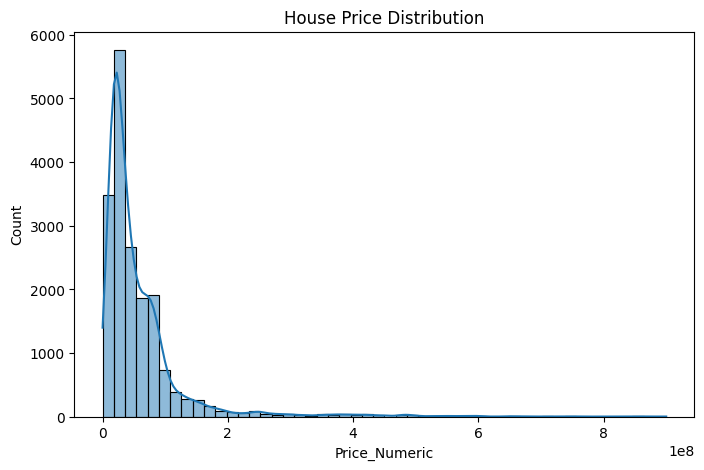

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price_Numeric"], bins=50, kde=True)
plt.title("House Price Distribution")
plt.show()

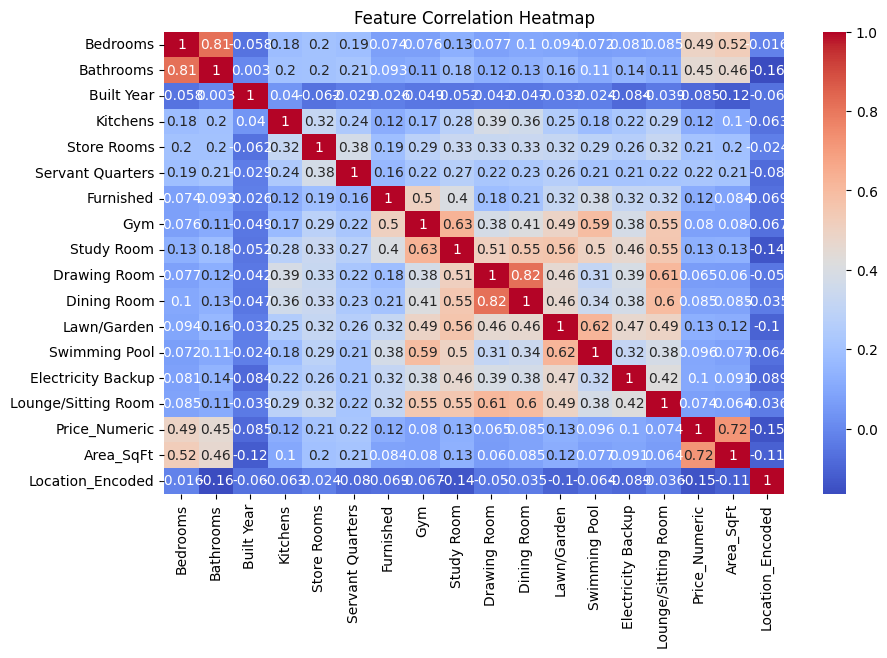

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

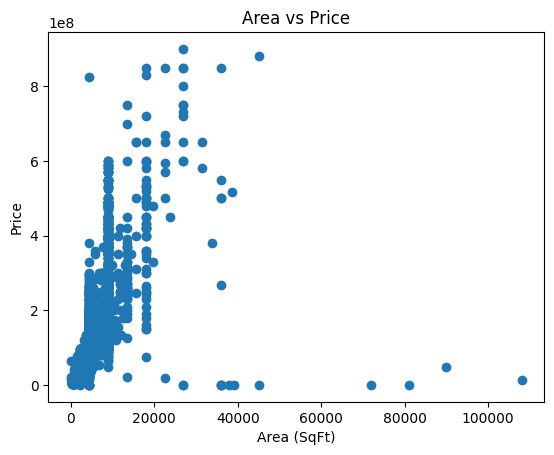

In [15]:
plt.scatter(df["Area_SqFt"], df["Price_Numeric"])
plt.xlabel("Area (SqFt)")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [16]:
features = [
    "Area_SqFt",
    "Bedrooms",
    "Bathrooms",
    "Location_Encoded",
    "Built Year",
]

X = df[features]
y = df["Price_Numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective="reg:squarederror",
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [17]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(" Model Performance")
print("-" * 30)
print(f"MAE  : PKR {mae:,.0f}")
print(f"RMSE : PKR {rmse:,.0f}")
print(f"R2   : {r2:.4f}")

 Model Performance
------------------------------
MAE  : PKR 13,359,576
RMSE : PKR 35,455,417
R2   : 0.7553


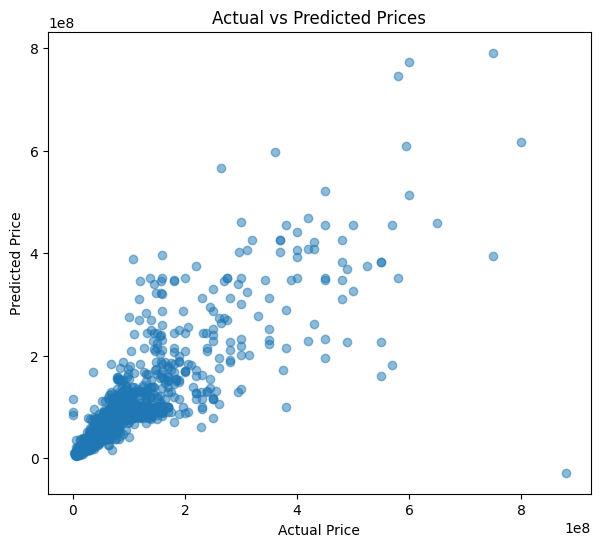

In [18]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

In [19]:
pickle.dump(model, open("house_model.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Model saved successfully!")

Model saved successfully!


In [20]:
sample = pd.DataFrame([[1125, 3, 2, 0, 2023]], columns=features)

pred = model.predict(sample)

print("Predicted House Price:", pred[0])

Predicted House Price: 9.54116e+06
